## Deducción de la Función de Transferencia $H(s)$

> **Nota:** Debido a que el nodo de entrada $PA$ está conectado directamente al nodo $V_L$ mediante un conductor ideal, ambos voltajes son equivalentes ($V_L = PA$ y $V_L(s) = PA(s)$).

### 1. Impedancia del Primer Bloque ($Z_1$)
Corresponde al arreglo en paralelo de la resistencia $R_c$ y el inductor $L$:

$$Z_1(s) = R_c \parallel sL = \frac{R_c \cdot sL}{R_c + sL}$$

### 2. Impedancia del Segundo Bloque ($Z_2$)
Corresponde al arreglo en paralelo del capacitor $C$ y la resistencia de carga $R_p$:

$$Z_2(s) = R_p \parallel \frac{1}{sC} = \frac{R_p \cdot \frac{1}{sC}}{R_p + \frac{1}{sC}} = \frac{R_p}{1 + s C R_p}$$

### 3. Impedancia Total del Circuito ($Z_{\text{total}}$)
Como ambos bloques están conectados en serie, la impedancia equivalente vista desde la entrada es la suma de $Z_1(s)$ y $Z_2(s)$:

$$Z_{\text{total}}(s) = Z_1(s) + Z_2(s) = \frac{R_c s L}{R_c + s L} + \frac{R_p}{1 + s C R_p}$$

---

### 4. Ecuación para el Voltaje $V_L$ ($PA$)
Aplicando la Ley de Ohm generalizada en el dominio de Laplace, el voltaje $V_L(s)$ (equivalente a $PA(s)$) en función del flujo de entrada $Q(s)$ es:

$$V_L(s) = PA(s) = Q(s) \cdot Z_{\text{total}}(s) = Q(s) \left( \frac{R_c s L}{R_c + s L} + \frac{R_p}{1 + s C R_p} \right)$$

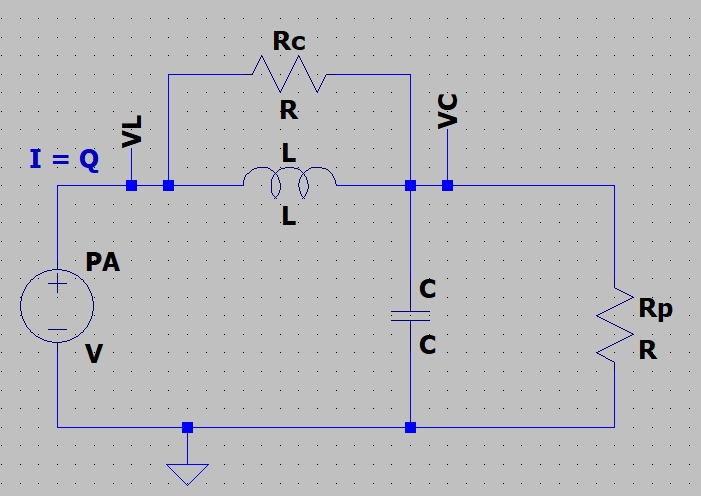
---

### 5. Función de Transferencia $H(s)$
La función de transferencia $H(s)$ se define como la relación entre la respuesta de voltaje $V_L(s)$ (o $PA(s)$) y la entrada de corriente $Q(s)$:

$$H(s) = \frac{V_L(s)}{Q(s)} = \frac{PA(s)}{Q(s)} = \frac{R_c s L}{R_c + s L} + \frac{R_p}{1 + s C R_p}$$

Agrupando los términos en una sola fracción con el mínimo común denominador, se obtiene la **forma polinomial canónica**:

$$H(s) = \frac{(R_c R_p L C) \, s^2 + (R_c L + R_p L) \, s + R_c R_p}{(R_p L C) \, s^2 + (R_c R_p C + L) \, s + R_c}$$

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
import scipy.signal as signal

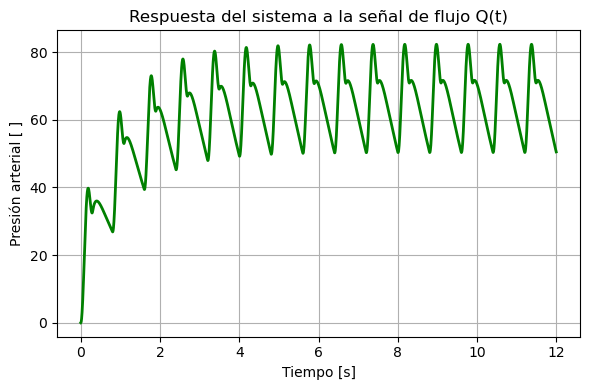

In [10]:
# Parámetros
Q_max = 500.0  # Flujo máximo
Ts = 0.3       # Tiempo de sístole [segundos]
Td = 0.5       # Tiempo de diástole [segundos]
T = Ts + Td    # Periodo total de un ciclo cardíaco (0.8 s ≈ 75 bpm)
Rc = 0.055       # Resistencia de la arteria
Rp = 0.7       # Resistencia periférica
L = 0.005       # Inductancia
C = 1.5       # Capacitancia



numerador=[(Rc*Rp*L*C),(Rc*L+Rp*L), (Rc*Rp)]
denominador=[(Rp*L*C),(Rc*Rp*C+L), Rc]


sys_tf = signal.TransferFunction(numerador, denominador)



time = np.linspace(0, 12, 3000)
# Tiempo relativo dentro de cada ciclo (de 0 a T)
t_cycle = time % T

# Señal Q(t) periódica
Q = np.where(t_cycle <= Ts, Q_max * (np.sin(np.pi * t_cycle / Ts))**2, 0)

t_out, y_out, _ = signal.lsim(sys_tf, Q, T=time)

plt.figure(figsize=(6, 4))
plt.plot(t_out, y_out, color='green', linewidth=2)
plt.title('Respuesta del sistema a la señal de flujo Q(t)')
plt.xlabel('Tiempo [s]')
plt.ylabel('Presión arterial [ ]')
plt.grid(True)
plt.tight_layout()
plt.show()

### Parámetros del Modelo: Sujeto Sano Adulto (35–55 años)

Basado principalmente en el estudio Asklepios (2404 sujetos sanos, 35–55 años), así como en los trabajos de Stergiopulos et al. y el Framingham Heart Study. Estos valores representan el comportamiento hemodinámico base de un sistema cardiovascular sin patologías, con reflexiones de onda normales (patrón tipo A).

**Valores Seleccionados (promedios del sujeto sano):**

* **$R_c$:** 0.055 mmHg·s/mL (Rango: 0.045–0.070)
* **$R_p$:** 0.75 mmHg·s/mL (Rango: 0.6–0.9)
* **$C$:** 1.5 mL/mmHg (Rango: 1.2–2.5)
* **$L$:** 0.005 mmHg·s²/mL (Rango: 0.005–0.006)
* **$Q_{max}$:** 550.0 mL/s (Rango: 450–650)
* **$T_s$:** 0.300 s (Rango: 280–340 ms)
* **$T_d$:** 0.530 s (Rango: 450–550 ms, ajustado para un ciclo $T$ de 0.830 s, equivalente a 72 lpm)

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

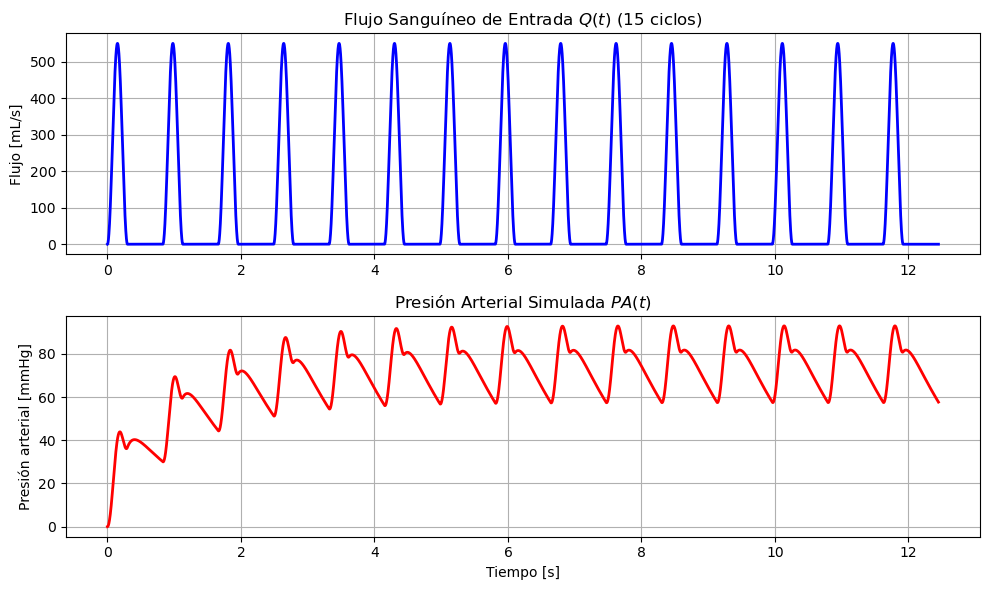

In [12]:
# --- 1. Parámetros del modelo (Sujeto sano adulto 35-55 años) ---
Rc = 0.055      # Resistencia característica aórtica [mmHg*s/mL]
Rp = 0.75       # Resistencia periférica total [mmHg*s/mL]
C = 1.5         # Compliancia arterial total [mL/mmHg]
L = 0.005       # Inercia arterial total [mmHg*s^2/mL]

# --- 2. Parámetros de la señal de entrada (Flujo Q) ---
Q_max = 550.0   # Flujo sanguíneo máximo [mL/s]
Ts = 0.300      # Tiempo de sístole [s] (300 ms)
Td = 0.530      # Tiempo de diástole [s] (Para que T total sea ~830 ms)
T = Ts + Td     # Periodo total de un ciclo cardíaco (0.830 s)

# --- 3. Control del Tiempo de Simulación ---
num_ciclos = 15 # Modifica este valor para ver más o menos ciclos
fs = 1000       # Frecuencia de muestreo [Hz]
time = np.arange(0, num_ciclos * T, 1/fs) 

# --- 4. Construcción de la Función de Transferencia H(s) ---
numerador = [(Rc*Rp*L*C), (Rc*L + Rp*L), (Rc*Rp)]
denominador = [(Rp*L*C), (Rc*Rp*C + L), Rc]

sys_tf = signal.TransferFunction(numerador, denominador)

# --- 5. Generación de la señal Q(t) vectorizada ---
t_cycle = time % T
Q = np.where(t_cycle <= Ts, Q_max * (np.sin(np.pi * t_cycle / Ts))**2, 0)

# --- 6. Simulación de la Presión Arterial ---
t_out, PA, _ = signal.lsim(sys_tf, Q, T=time)

# --- 7. Visualización ---
plt.figure(figsize=(10, 6))

# Gráfica del Flujo de entrada
plt.subplot(2, 1, 1)
plt.plot(time, Q, color='blue', linewidth=2)
plt.title(f'Flujo Sanguíneo de Entrada $Q(t)$ ({num_ciclos} ciclos)')
plt.ylabel('Flujo [mL/s]')
plt.grid(True)

# Gráfica de la Presión de salida
plt.subplot(2, 1, 2)
plt.plot(t_out, PA, color='red', linewidth=2)
plt.title('Presión Arterial Simulada $PA(t)$')
plt.xlabel('Tiempo [s]')
plt.ylabel('Presión arterial [mmHg]')
plt.grid(True)

plt.tight_layout()
plt.show()

### Parámetros del Modelo: Hipertensión Arterial Sistémica (Severa)

Los cambios principales reflejan el aumento drástico en las resistencias ($R_c$ y $R_p$) y la caída en la compliancia ($C$), lo que simula arterias más rígidas y estrechas. 

**Valores Seleccionados (promedios del rango hipertenso):**

* **$R_c$:** 0.115 mmHg·s/mL (Rango: 0.08–0.15)
* **$R_p$:** 1.6 mmHg·s/mL (Rango: 1.2–2.0)
* **$C$:** 0.8 mL/mmHg (Rango: 0.6–1.0)
* **$L$:** 0.005 mmHg·s²/mL (Rango: 0.004–0.006)
* **$Q_{max}$:** 575.0 mL/s (Rango: 500–650)
* **$T_s$:** 0.315 s (Rango: 290–340 ms)
* **$T_d$:** 0.435 s (Se elige para un ciclo $T$ de 0.750 s, equivalente a 80 lpm, dentro del rango de 75-85 lpm)

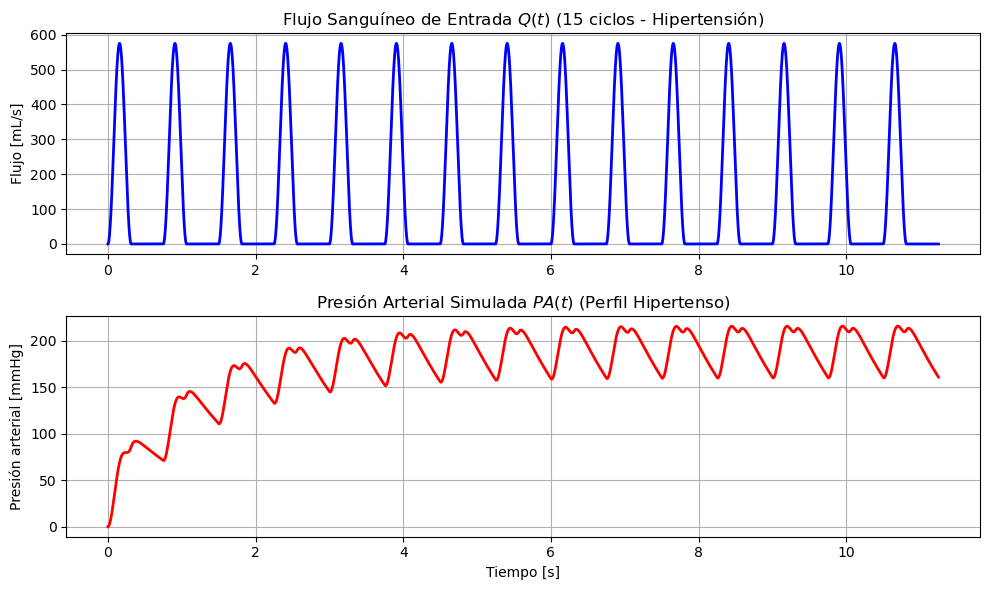

In [13]:
# --- 1. Parámetros del modelo (Hipertensión severa) ---
Rc = 0.115      # Resistencia característica aórtica [mmHg*s/mL]
Rp = 1.6        # Resistencia periférica total [mmHg*s/mL]
C = 0.8         # Compliancia arterial total [mL/mmHg] (reducida por rigidez)
L = 0.005       # Inercia arterial total [mmHg*s^2/mL]

# --- 2. Parámetros de la señal de entrada (Flujo Q) ---
Q_max = 575.0   # Flujo sanguíneo máximo [mL/s]
Ts = 0.315      # Tiempo de sístole [s] (315 ms)
Td = 0.435      # Tiempo de diástole [s] (435 ms)
T = Ts + Td     # Periodo total de un ciclo cardíaco (0.750 s -> 80 bpm)

# --- 3. Control del Tiempo de Simulación ---
num_ciclos = 15 # Cantidad de ciclos a simular
fs = 1000       # Frecuencia de muestreo [Hz]
time = np.arange(0, num_ciclos * T, 1/fs) 

# --- 4. Construcción de la Función de Transferencia H(s) ---
numerador = [(Rc*Rp*L*C), (Rc*L + Rp*L), (Rc*Rp)]
denominador = [(Rp*L*C), (Rc*Rp*C + L), Rc]

sys_tf = signal.TransferFunction(numerador, denominador)

# --- 5. Generación de la señal Q(t) vectorizada ---
t_cycle = time % T
Q = np.where(t_cycle <= Ts, Q_max * (np.sin(np.pi * t_cycle / Ts))**2, 0)

# --- 6. Simulación de la Presión Arterial ---
t_out, PA, _ = signal.lsim(sys_tf, Q, T=time)

# --- 7. Visualización ---
plt.figure(figsize=(10, 6))

# Gráfica del Flujo de entrada
plt.subplot(2, 1, 1)
plt.plot(time, Q, color='blue', linewidth=2)
plt.title(f'Flujo Sanguíneo de Entrada $Q(t)$ ({num_ciclos} ciclos - Hipertensión)')
plt.ylabel('Flujo [mL/s]')
plt.grid(True)

# Gráfica de la Presión de salida
plt.subplot(2, 1, 2)
plt.plot(t_out, PA, color='red', linewidth=2)
plt.title('Presión Arterial Simulada $PA(t)$ (Perfil Hipertenso)')
plt.xlabel('Tiempo [s]')
plt.ylabel('Presión arterial [mmHg]')
plt.grid(True)

plt.tight_layout()
plt.show()

### Parámetros del Modelo: Rigidez Arterial Aumentada / Arteriosclerosis

Esta condición se asocia al envejecimiento vascular y se caracteriza por la pérdida de elastina y aumento de colágeno en la pared arterial. El cambio más significativo es la reducción drástica de la compliancia ($C$) combinada con un aumento importante en la resistencia característica ($R_c$).

**Valores Seleccionados (promedios del rango de arteriosclerosis):**

* **$R_c$:** 0.160 mmHg·s/mL (Rango: 0.10–0.22)
* **$R_p$:** 1.00 mmHg·s/mL (Rango: 0.8–1.2)
* **$C$:** 0.70 mL/mmHg (Rango: 0.5–0.9)
* **$L$:** 0.0045 mmHg·s²/mL (Rango: 0.004–0.005)
* **$Q_{max}$:** 475.0 mL/s (Rango: 400–550)
* **$T_s$:** 0.325 s (Rango: 300–350 ms)
* **$T_d$:** 0.505 s (Se elige para un ciclo $T$ de 0.830 s, equivalente a ~72 lpm, dentro del rango de 65-75 lpm)

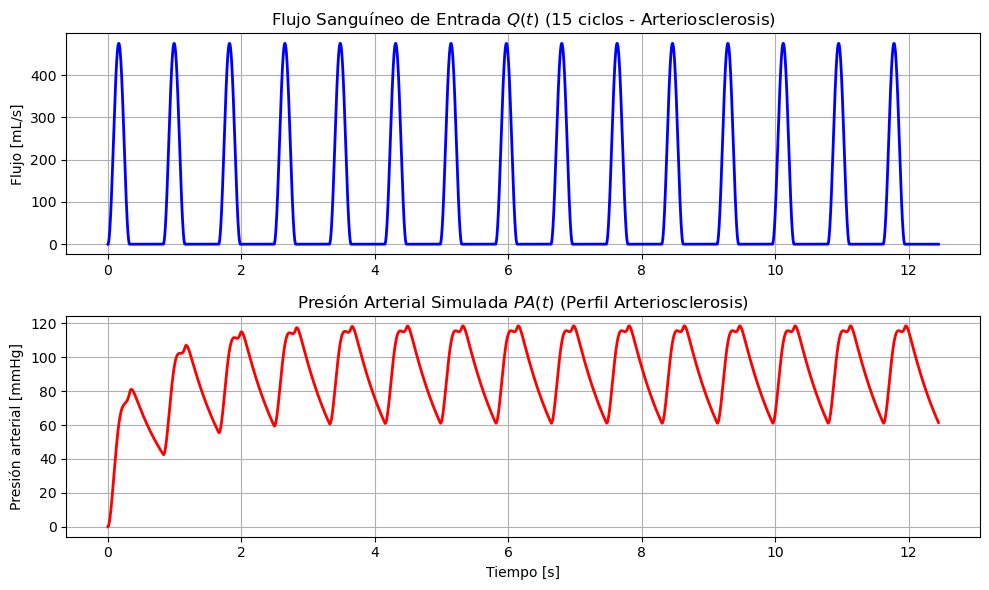

In [14]:
# --- 1. Parámetros del modelo (Arteriosclerosis) ---
Rc = 0.160      # Resistencia característica aórtica [mmHg*s/mL]
Rp = 1.00       # Resistencia periférica total [mmHg*s/mL]
C = 0.70        # Compliancia arterial total [mL/mmHg] (muy reducida por pérdida de elastina)
L = 0.0045      # Inercia arterial total [mmHg*s^2/mL]

# --- 2. Parámetros de la señal de entrada (Flujo Q) ---
Q_max = 475.0   # Flujo sanguíneo máximo [mL/s] (ligera reducción)
Ts = 0.325      # Tiempo de sístole [s] (325 ms)
Td = 0.505      # Tiempo de diástole [s] (505 ms)
T = Ts + Td     # Periodo total de un ciclo cardíaco (0.830 s -> ~72 bpm)

# --- 3. Control del Tiempo de Simulación ---
num_ciclos = 15 # Cantidad de ciclos a simular
fs = 1000       # Frecuencia de muestreo [Hz]
time = np.arange(0, num_ciclos * T, 1/fs) 

# --- 4. Construcción de la Función de Transferencia H(s) ---
numerador = [(Rc*Rp*L*C), (Rc*L + Rp*L), (Rc*Rp)]
denominador = [(Rp*L*C), (Rc*Rp*C + L), Rc]

sys_tf = signal.TransferFunction(numerador, denominador)

# --- 5. Generación de la señal Q(t) vectorizada ---
t_cycle = time % T
Q = np.where(t_cycle <= Ts, Q_max * (np.sin(np.pi * t_cycle / Ts))**2, 0)

# --- 6. Simulación de la Presión Arterial ---
t_out, PA, _ = signal.lsim(sys_tf, Q, T=time)

# --- 7. Visualización ---
plt.figure(figsize=(10, 6))

# Gráfica del Flujo de entrada
plt.subplot(2, 1, 1)
plt.plot(time, Q, color='blue', linewidth=2)
plt.title(f'Flujo Sanguíneo de Entrada $Q(t)$ ({num_ciclos} ciclos - Arteriosclerosis)')
plt.ylabel('Flujo [mL/s]')
plt.grid(True)

# Gráfica de la Presión de salida
plt.subplot(2, 1, 2)
plt.plot(t_out, PA, color='red', linewidth=2)
plt.title('Presión Arterial Simulada $PA(t)$ (Perfil Arteriosclerosis)')
plt.xlabel('Tiempo [s]')
plt.ylabel('Presión arterial [mmHg]')
plt.grid(True)

plt.tight_layout()
plt.show()